# Validation notebook: comparison of rock energy segmentation methods

Вход: `united_rock_energy_features_all_methods.csv`

Notebook сравнивает пять способов разметки энергоёмкости:

1. `energy_type_kmeans`
2. `energy_type_gmm`
3. `energy_type_quantile`
4. `energy_type_rule_based`
5. `energy_type_segment_quantile`

Валидация:
- физическая осмысленность классов;
- control leakage check;
- temporal stability;
- переносимость между wells;
- полезность labels/hardness для прогноза ROP.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error
    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

RANDOM_STATE = 42
EPS = 1e-6

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Загрузка датасета со всеми методами разметки

In [2]:
DATA_PATH = "united_rock_energy_features_all_methods.csv"

df = pd.read_csv(DATA_PATH)
df["processing_time"] = pd.to_datetime(df["processing_time"])
df = df.sort_values(["well_id", "processing_time"]).reset_index(drop=True)

segmentation_methods = [
    "energy_type_kmeans",
    "energy_type_gmm",
    "energy_type_quantile",
    "energy_type_rule_based",
    "energy_type_segment_quantile",
]

required_cols = [
    "processing_time",
    "well_id",
    "pressure_axis",
    "pressure_rotation",
    "rotation",
    "speed",
    "energy_input_proxy",
    "pseudo_mse",
    "drilling_efficiency",
    "formation_residual",
    "hardness_score_smooth",
] + segmentation_methods

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Не хватает колонок: {missing}")

print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
display(df[required_cols].head())

Loaded: united_rock_energy_features_all_methods.csv
Shape: (415049, 127)


,processing_time,well_id,pressure_axis,pressure_rotation,rotation,speed,energy_input_proxy,pseudo_mse,drilling_efficiency,formation_residual,hardness_score_smooth,energy_type_kmeans,energy_type_gmm,energy_type_quantile,energy_type_rule_based,energy_type_segment_quantile
0,2025-08-24 10:09:50.980,19601,804,4551,74.256,0.002755,338743.056,1.229314e+08,8.131666e-09,-0.005300,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-08-24 10:10:00.260,19601,763,3782,73.812,0.003030,279919.984,9.235235e+07,1.082452e-08,-0.005025,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-08-24 10:10:05.199,19601,879,4407,73.512,0.006060,324846.384,5.359617e+07,1.865497e-08,-0.001995,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-08-24 10:10:14.610,19601,721,3705,73.962,0.002755,274750.210,9.970810e+07,1.002564e-08,-0.005300,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-08-24 10:10:34.197,19601,859,3883,74.256,0.001515,289195.048,1.907619e+08,5.238679e-09,-0.006540,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Универсальные функции валидации

In [3]:
def summarize_energy_clusters(data, type_col):
    return (
        data
        .groupby(type_col)
        .agg(
            rows=("speed", "size"),
            speed_median=("speed", "median"),
            speed_mean=("speed", "mean"),
            pseudo_mse_median=("pseudo_mse", "median"),
            pseudo_mse_smooth=("pseudo_mse_roll_median_60", "median"),
            efficiency_median=("drilling_efficiency", "median"),
            efficiency_smooth=("drilling_efficiency_roll_median_60", "median"),
            residual_median=("formation_residual", "median"),
            residual_smooth=("formation_residual_roll_median_60", "median"),
            relative_residual_smooth=("relative_formation_residual_roll_median_60", "median"),
            hardness_median=("hardness_score", "median"),
            hardness_smooth=("hardness_score_smooth", "median"),
            speed_std_smooth=("speed_roll_std_60", "median"),
            rotation_std_smooth=("rotation_roll_std_60", "median"),
            pressure_axis_median=("pressure_axis", "median"),
            pressure_rotation_median=("pressure_rotation", "median"),
            rotation_median=("rotation", "median"),
            energy_input_median=("energy_input_proxy", "median"),
        )
        .sort_values("hardness_smooth")
    )


def physical_score(summary_df):
    # Чем лучше монотонность soft->hard, тем больше score.
    # Ожидаем: pseudo_mse ↑, hardness ↑, speed ↓, efficiency ↓, residual ↓.
    s = summary_df.copy().sort_values("hardness_smooth")
    score = 0

    def mono_inc(x):
        return np.all(np.diff(x) >= 0)

    def mono_dec(x):
        return np.all(np.diff(x) <= 0)

    score += int(mono_inc(s["hardness_smooth"].values))
    score += int(mono_inc(s["pseudo_mse_smooth"].values))
    score += int(mono_dec(s["efficiency_smooth"].values))
    score += int(mono_dec(s["residual_smooth"].values))
    score += int(mono_dec(s["speed_median"].values))

    return score


def control_leakage_check(data, type_col):
    return (
        data
        .groupby(type_col)
        .agg(
            rows=("speed", "size"),
            pressure_axis_median=("pressure_axis", "median"),
            pressure_axis_q25=("pressure_axis", lambda s: s.quantile(0.25)),
            pressure_axis_q75=("pressure_axis", lambda s: s.quantile(0.75)),
            pressure_rotation_median=("pressure_rotation", "median"),
            pressure_rotation_q25=("pressure_rotation", lambda s: s.quantile(0.25)),
            pressure_rotation_q75=("pressure_rotation", lambda s: s.quantile(0.75)),
            rotation_median=("rotation", "median"),
            speed_median=("speed", "median"),
            pseudo_mse_smooth=("pseudo_mse_roll_median_60", "median"),
            efficiency_smooth=("drilling_efficiency_roll_median_60", "median"),
            residual_smooth=("formation_residual_roll_median_60", "median"),
            hardness_smooth=("hardness_score_smooth", "median"),
        )
        .sort_values("hardness_smooth")
    )


def temporal_stability(data, type_col):
    tmp = data.sort_values(["well_id", "processing_time"]).copy()
    tmp["prev_type"] = tmp.groupby("well_id")[type_col].shift(1)
    tmp["changed"] = (tmp[type_col] != tmp["prev_type"]) & tmp["prev_type"].notna()

    report = (
        tmp.groupby("well_id")
           .agg(
               rows=(type_col, "size"),
               changes=("changed", "sum"),
           )
    )

    report["changes_per_1000_points"] = 1000 * report["changes"] / report["rows"]
    return report


def per_well_class_consistency(data, type_col):
    report = (
        data
        .groupby(["well_id", type_col])
        .agg(
            rows=("speed", "size"),
            pseudo_mse_smooth=("pseudo_mse_roll_median_60", "median"),
            efficiency_smooth=("drilling_efficiency_roll_median_60", "median"),
            residual_smooth=("formation_residual_roll_median_60", "median"),
            hardness_smooth=("hardness_score_smooth", "median"),
        )
        .reset_index()
    )

    consistency = (
        report
        .groupby(type_col)
        .agg(
            wells=("well_id", "nunique"),
            median_hardness=("hardness_smooth", "median"),
            std_hardness=("hardness_smooth", "std"),
            median_pseudo_mse=("pseudo_mse_smooth", "median"),
            std_pseudo_mse=("pseudo_mse_smooth", "std"),
            median_residual=("residual_smooth", "median"),
            std_residual=("residual_smooth", "std"),
        )
        .sort_values("median_hardness")
    )

    return consistency

## 3. Сводки и физическая монотонность по всем методам

In [4]:
summaries = {}
physical_scores = []

for method in segmentation_methods:
    print("\n" + "=" * 100)
    print(method)
    summary = summarize_energy_clusters(df, method)
    summaries[method] = summary
    display(summary)

    score = physical_score(summary)
    physical_scores.append({"method": method, "physical_monotonicity_score_0_5": score})

physical_scores_df = pd.DataFrame(physical_scores).sort_values("physical_monotonicity_score_0_5", ascending=False)
display(physical_scores_df)


energy_type_kmeans


,rows,speed_median,speed_mean,pseudo_mse_median,pseudo_mse_smooth,efficiency_median,efficiency_smooth,residual_median,residual_smooth,relative_residual_smooth,hardness_median,hardness_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median,energy_input_median
energy_type_kmeans,,,,,,,,,,,,,,,,,,
soft_low_energy,58853,0.02121,0.021956,6.754376e+07,7.297385e+07,1.480461e-08,1.370572e-08,0.007810,0.004854,0.366668,-2.429630,-2.672623,0.005814,2.574809,17195.0,14160.0,103.308,1488004.342
medium_low_energy,70095,0.01212,0.011197,1.375086e+08,9.538767e+07,7.271551e-09,1.048473e-08,-0.002390,0.001632,0.117623,0.533814,-1.094870,0.005624,4.912488,18062.0,14748.0,103.602,1573057.740
medium_high_energy,129318,0.01515,0.015654,1.037637e+08,1.288308e+08,9.636621e-09,7.762442e-09,0.002067,-0.001131,-0.090336,-0.690013,0.344682,0.004416,1.328833,20190.0,15470.0,102.714,1616134.133
hard_high_energy,124369,0.00606,0.007377,2.233127e+08,1.611613e+08,4.477273e-09,6.206590e-09,-0.004854,-0.003151,-0.262833,1.821581,1.559755,0.003995,1.584550,19405.0,14510.0,103.308,1537123.018



energy_type_gmm


,rows,speed_median,speed_mean,pseudo_mse_median,pseudo_mse_smooth,efficiency_median,efficiency_smooth,residual_median,residual_smooth,relative_residual_smooth,hardness_median,hardness_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median,energy_input_median
energy_type_gmm,,,,,,,,,,,,,,,,,,
soft_low_energy,48316,0.01818,0.018270,6.889436e+07,7.227633e+07,1.451401e-08,1.383792e-08,0.005540,0.001330,0.113200,-2.077888,-1.881694,0.005495,5.926444,15067.0,11526.0,103.704,1194177.379
medium_low_energy,90074,0.01515,0.015678,9.317660e+07,8.772975e+07,1.073155e-08,1.139930e-08,0.002123,0.002532,0.180551,-0.910077,-1.561306,0.005531,2.458324,17410.0,14334.0,103.308,1514089.719
medium_high_energy,122965,0.01212,0.014674,1.207331e+08,1.265284e+08,8.282144e-09,7.903647e-09,0.000444,-0.000605,-0.046943,-0.150090,0.184594,0.004487,1.273967,20572.0,16115.0,102.816,1684847.888
hard_high_energy,121280,0.00606,0.007581,2.261081e+08,1.690452e+08,4.421968e-09,5.918563e-09,-0.004693,-0.003100,-0.270388,1.838031,1.684015,0.003975,1.719319,19473.0,14356.0,103.458,1521607.128



energy_type_quantile


...


energy_type_rule_based


,rows,speed_median,speed_mean,pseudo_mse_median,pseudo_mse_smooth,efficiency_median,efficiency_smooth,residual_median,residual_smooth,relative_residual_smooth,hardness_median,hardness_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median,energy_input_median
energy_type_rule_based,,,,,,,,,,,,,,,,,,
soft_low_energy,95653,0.018180,0.017267,8.332718e+07,7.791739e+07,1.200001e-08,1.283523e-08,0.003501,0.003777,0.278844,-1.383032,-2.205046,0.005761,2.814554,16720.0,13605.0,103.410,1430114.622
medium_low_energy,96202,0.013773,0.014469,1.177907e+08,1.114920e+08,8.489064e-09,8.969926e-09,0.000784,0.000781,0.055265,-0.251865,-0.412886,0.004752,1.595440,20341.0,15720.0,103.008,1657545.544
medium_high_energy,95098,0.012120,0.011600,1.378456e+08,1.364802e+08,7.253809e-09,7.327845e-09,-0.001958,-0.002104,-0.157814,0.494826,0.746105,0.004449,1.411716,19636.0,15160.0,102.864,1589148.153
hard_high_energy,95682,0.006060,0.009115,1.903628e+08,1.898602e+08,5.252386e-09,5.274633e-09,-0.003356,-0.003589,-0.311162,1.347597,2.032597,0.003760,1.691286,19682.0,14484.0,103.458,1537272.999



energy_type_segment_quantile


,rows,speed_median,speed_mean,pseudo_mse_median,pseudo_mse_smooth,efficiency_median,efficiency_smooth,residual_median,residual_smooth,relative_residual_smooth,hardness_median,hardness_smooth,speed_std_smooth,rotation_std_smooth,pressure_axis_median,pressure_rotation_median,rotation_median,energy_input_median
energy_type_segment_quantile,,,,,,,,,,,,,,,,,,
soft_low_energy,94049,0.01818,0.018020,8.558967e+07,7.974684e+07,1.168269e-08,1.254017e-08,0.003915,0.003969,0.291887,-1.396430,-2.194668,0.005584,2.185543,17867.0,14759.0,103.308,1554756.032
medium_low_energy,96213,0.01212,0.013806,1.168919e+08,1.116768e+08,8.554255e-09,8.954801e-09,0.000251,0.000290,0.022194,-0.192362,-0.354254,0.004820,1.895180,19606.0,15166.0,103.008,1593824.100
medium_high_energy,95943,0.01212,0.011592,1.386117e+08,1.369806e+08,7.213805e-09,7.300751e-09,-0.001748,-0.001792,-0.139816,0.475784,0.714666,0.004383,1.367448,20037.0,15180.0,102.966,1595171.720
hard_high_energy,96430,0.00606,0.009162,1.865875e+08,1.858249e+08,5.358731e-09,5.388009e-09,-0.003570,-0.003750,-0.317930,1.353620,1.983451,0.003855,1.771645,19231.0,14404.0,103.410,1525925.468


,method,physical_monotonicity_score_0_5
2,energy_type_quantile,5
4,energy_type_segment_quantile,5
3,energy_type_rule_based,5
0,energy_type_kmeans,4
1,energy_type_gmm,4


## 4. Control leakage check

In [5]:
for method in segmentation_methods:
    print("\n" + "=" * 100)
    print(method)
    display(control_leakage_check(df, method))


energy_type_kmeans


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,rotation_median,speed_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,hardness_smooth
energy_type_kmeans,,,,,,,,,,,,,
soft_low_energy,58853,17195.0,14141.0,19958.0,14160.0,11176.0,16150.0,103.308,0.02121,7.297385e+07,1.370572e-08,0.004854,-2.672623
medium_low_energy,70095,18062.0,14991.5,20548.0,14748.0,11717.0,16558.0,103.602,0.01212,9.538767e+07,1.048473e-08,0.001632,-1.094870
medium_high_energy,129318,20190.0,17894.0,21283.0,15470.0,13878.0,16825.0,102.714,0.01515,1.288308e+08,7.762442e-09,-0.001131,0.344682
hard_high_energy,124369,19405.0,16956.0,20967.0,14510.0,12541.0,16230.0,103.308,0.00606,1.611613e+08,6.206590e-09,-0.003151,1.559755



energy_type_gmm


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,rotation_median,speed_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,hardness_smooth
energy_type_gmm,,,,,,,,,,,,,
soft_low_energy,48316,15067.0,10902.0,17822.0,11526.0,9563.0,13927.25,103.704,0.01818,7.227633e+07,1.383792e-08,0.001330,-1.881694
medium_low_energy,90074,17410.0,14982.0,20012.0,14334.0,11704.0,16297.00,103.308,0.01515,8.772975e+07,1.139930e-08,0.002532,-1.561306
medium_high_energy,122965,20572.0,19254.0,21474.0,16115.0,14992.0,17269.00,102.816,0.01212,1.265284e+08,7.903647e-09,-0.000605,0.184594
hard_high_energy,121280,19473.0,17166.0,21007.0,14356.0,12634.0,15967.25,103.458,0.00606,1.690452e+08,5.918563e-09,-0.003100,1.684015



energy_type_quantile


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,rotation_median,speed_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,hardness_smooth
energy_type_quantile,,,,,,,,,,,,,
soft_low_energy,95659,17842.0,14916.0,20390.0,14740.0,11735.0,16546.0,103.308,0.01818,7.893292e+07,1.266945e-08,0.004005,-2.212806
medium_low_energy,95661,19628.0,16863.0,21032.0,15178.0,13094.0,16667.0,103.008,0.01212,1.115156e+08,8.968309e-09,0.000256,-0.352565
medium_high_energy,95656,20085.0,17478.0,21243.0,15244.0,13428.0,16666.0,102.912,0.01212,1.371730e+08,7.290481e-09,-0.001889,0.736440
hard_high_energy,95659,19187.0,16884.0,20842.0,14331.0,12506.0,16080.0,103.458,0.00606,1.898602e+08,5.274633e-09,-0.003889,2.035933



energy_type_rule_based


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,rotation_median,speed_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,hardness_smooth
energy_type_rule_based,,,,,,,,,,,,,
soft_low_energy,95653,16720.0,13297.0,19409.0,13605.0,10648.0,15898.00,103.410,0.018180,7.791739e+07,1.283523e-08,0.003777,-2.205046
medium_low_energy,96202,20341.0,18194.0,21343.0,15720.0,14221.0,17049.75,103.008,0.013773,1.114920e+08,8.969926e-09,0.000781,-0.412886
medium_high_energy,95098,19636.0,17033.0,20987.0,15160.0,13179.0,16640.00,102.864,0.012120,1.364802e+08,7.327845e-09,-0.002104,0.746105
hard_high_energy,95682,19682.0,17380.0,21134.0,14484.0,12765.0,16151.00,103.458,0.006060,1.898602e+08,5.274633e-09,-0.003589,2.032597



energy_type_segment_quantile


,rows,pressure_axis_median,pressure_axis_q25,pressure_axis_q75,pressure_rotation_median,pressure_rotation_q25,pressure_rotation_q75,rotation_median,speed_median,pseudo_mse_smooth,efficiency_smooth,residual_smooth,hardness_smooth
energy_type_segment_quantile,,,,,,,,,,,,,
soft_low_energy,94049,17867.0,14983.0,20414.0,14759.0,11754.0,16537.0,103.308,0.01818,7.974684e+07,1.254017e-08,0.003969,-2.194668
medium_low_energy,96213,19606.0,16795.0,21028.0,15166.0,13035.0,16675.0,103.008,0.01212,1.116768e+08,8.954801e-09,0.000290,-0.354254
medium_high_energy,95943,20037.0,17409.0,21218.0,15180.0,13353.0,16609.0,102.966,0.01212,1.369806e+08,7.300751e-09,-0.001792,0.714666
hard_high_energy,96430,19231.0,16949.0,20851.0,14404.0,12569.0,16162.0,103.410,0.00606,1.858249e+08,5.388009e-09,-0.003750,1.983451


## 5. Temporal stability comparison

In [6]:
stability_rows = []
stability_reports = {}

for method in segmentation_methods:
    report = temporal_stability(df, method)
    stability_reports[method] = report

    desc = report["changes_per_1000_points"].describe(percentiles=[.05, .5, .95])

    stability_rows.append({
        "method": method,
        "mean_changes_per_1000": desc["mean"],
        "median_changes_per_1000": desc["50%"],
        "p95_changes_per_1000": desc["95%"],
        "max_changes_per_1000": desc["max"],
    })

stability_compare = pd.DataFrame(stability_rows).sort_values("median_changes_per_1000")
display(stability_compare)

for method in segmentation_methods:
    print("\n" + "=" * 100)
    print(method)
    display(stability_reports[method].describe(percentiles=[.05, .5, .95]))

,method,mean_changes_per_1000,median_changes_per_1000,p95_changes_per_1000,max_changes_per_1000
4,energy_type_segment_quantile,5.183019,5.305077,12.269939,15.479876
3,energy_type_rule_based,24.695061,20.833333,66.031969,184.873950
2,energy_type_quantile,27.214285,23.910252,67.519647,176.470588
1,energy_type_gmm,241.479872,251.101322,428.470825,589.403974
0,energy_type_kmeans,347.540998,375.678531,511.596175,622.222222



energy_type_kmeans


,rows,changes,changes_per_1000_points
count,1706.000000,1706.000000,1706.000000
mean,243.287808,88.995311,347.540998
std,98.678279,51.732223,128.376683
min,50.000000,0.000000,0.000000
5%,98.000000,10.000000,70.954488
50%,235.500000,84.000000,375.678531
95%,417.000000,181.000000,511.596175
max,615.000000,303.000000,622.222222



energy_type_gmm


,rows,changes,changes_per_1000_points
count,1706.000000,1706.000000,1706.000000
mean,243.287808,63.228605,241.479872
std,98.678279,43.554859,118.740074
min,50.000000,0.000000,0.000000
5%,98.000000,4.000000,31.578947
50%,235.500000,57.000000,251.101322
95%,417.000000,142.000000,428.470825
max,615.000000,230.000000,589.403974


...

,rows,changes,changes_per_1000_points
count,1706.000000,1706.000000,1706.000000
mean,243.287808,6.962485,27.214285
std,98.678279,6.069567,22.266930
min,50.000000,0.000000,0.000000
5%,98.000000,0.000000,0.000000
50%,235.500000,6.000000,23.910252
95%,417.000000,18.000000,67.519647
max,615.000000,36.000000,176.470588



energy_type_rule_based


,rows,changes,changes_per_1000_points
count,1706.000000,1706.000000,1706.000000
mean,243.287808,6.417937,24.695061
std,98.678279,6.105572,21.421443
min,50.000000,0.000000,0.000000
5%,98.000000,0.000000,0.000000
50%,235.500000,5.000000,20.833333
95%,417.000000,18.000000,66.031969
max,615.000000,45.000000,184.873950



energy_type_segment_quantile


,rows,changes,changes_per_1000_points
count,1706.000000,1706.000000,1706.000000
mean,243.287808,1.374560,5.183019
std,98.678279,1.197176,4.180084
min,50.000000,0.000000,0.000000
5%,98.000000,0.000000,0.000000
50%,235.500000,1.000000,5.305077
95%,417.000000,4.000000,12.269939
max,615.000000,6.000000,15.479876


## 6. Переносимость между wells

In [7]:
for method in segmentation_methods:
    print("\n" + "=" * 100)
    print(method)
    display(per_well_class_consistency(df, method))


energy_type_kmeans


,wells,median_hardness,std_hardness,median_pseudo_mse,std_pseudo_mse,median_residual,std_residual
energy_type_kmeans,,,,,,,
soft_low_energy,1370,-1.906026,1.442995,8.252748e+07,2.441422e+07,0.003218,0.003394
medium_low_energy,1541,-1.086369,1.042594,9.471504e+07,1.806358e+07,0.001526,0.002657
medium_high_energy,1507,0.345326,0.925892,1.278490e+08,2.797040e+07,-0.001219,0.001975
hard_high_energy,1330,1.025441,0.910343,1.434523e+08,3.709780e+07,-0.002600,0.001814



energy_type_gmm


,wells,median_hardness,std_hardness,median_pseudo_mse,std_pseudo_mse,median_residual,std_residual
energy_type_gmm,,,,,,,
medium_low_energy,1466,-1.286175,1.108271,9.026779e+07,1.228138e+07,0.001885,0.003287
soft_low_energy,1679,-0.025204,2.231802,1.186745e+08,5.000650e+07,-0.000649,0.004457
medium_high_energy,1386,0.176207,0.791054,1.248727e+08,1.590745e+07,-0.000668,0.001958
hard_high_energy,1320,1.087310,0.987551,1.448217e+08,3.590518e+07,-0.002439,0.002106



energy_type_quantile


,wells,median_hardness,std_hardness,median_pseudo_mse,std_pseudo_mse,median_residual,std_residual
energy_type_quantile,,,,,,,
soft_low_energy,1200,-1.982462,1.085697,8.005601e+07,1.611584e+07,0.003509,0.002748
medium_low_energy,1347,-0.381814,0.331578,1.091400e+08,1.381528e+07,0.000051,0.001271
medium_high_energy,1205,0.722969,0.226302,1.352325e+08,1.249635e+07,-0.002033,0.000946
hard_high_energy,900,1.765119,0.561274,1.725030e+08,3.407908e+07,-0.003844,0.001323



energy_type_rule_based


,wells,median_hardness,std_hardness,median_pseudo_mse,std_pseudo_mse,median_residual,std_residual
energy_type_rule_based,,,,,,,
soft_low_energy,1267,-1.906147,1.288096,8.145314e+07,1.298841e+07,0.003073,0.003639
medium_low_energy,1307,-0.352258,0.477282,1.087211e+08,1.003393e+07,0.000511,0.001562
medium_high_energy,1204,0.718280,0.312661,1.357902e+08,9.816602e+06,-0.002133,0.001178
hard_high_energy,862,1.827734,0.651706,1.726071e+08,3.106094e+07,-0.003476,0.001602



energy_type_segment_quantile


,wells,median_hardness,std_hardness,median_pseudo_mse,std_pseudo_mse,median_residual,std_residual
energy_type_segment_quantile,,,,,,,
soft_low_energy,917,-2.138907,1.155152,8.037333e+07,1.648694e+07,0.003903,0.002768
medium_low_energy,950,-0.372527,0.362844,1.102983e+08,1.373232e+07,0.000262,0.001237
medium_high_energy,893,0.716309,0.255200,1.357621e+08,1.234937e+07,-0.001883,0.000916
hard_high_energy,669,1.828145,0.605053,1.760715e+08,3.580099e+07,-0.003720,0.001351


## 7. Визуализация по одному well_id

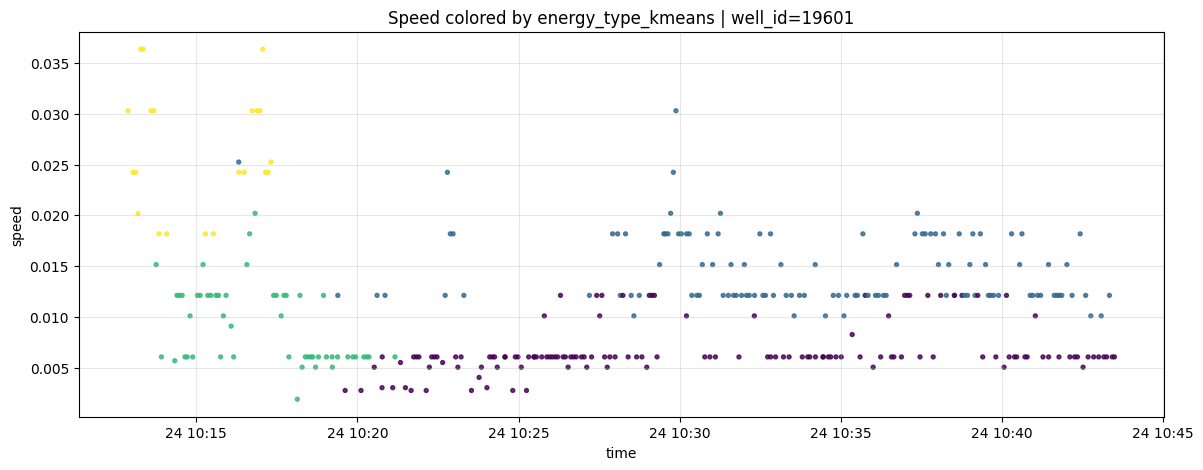

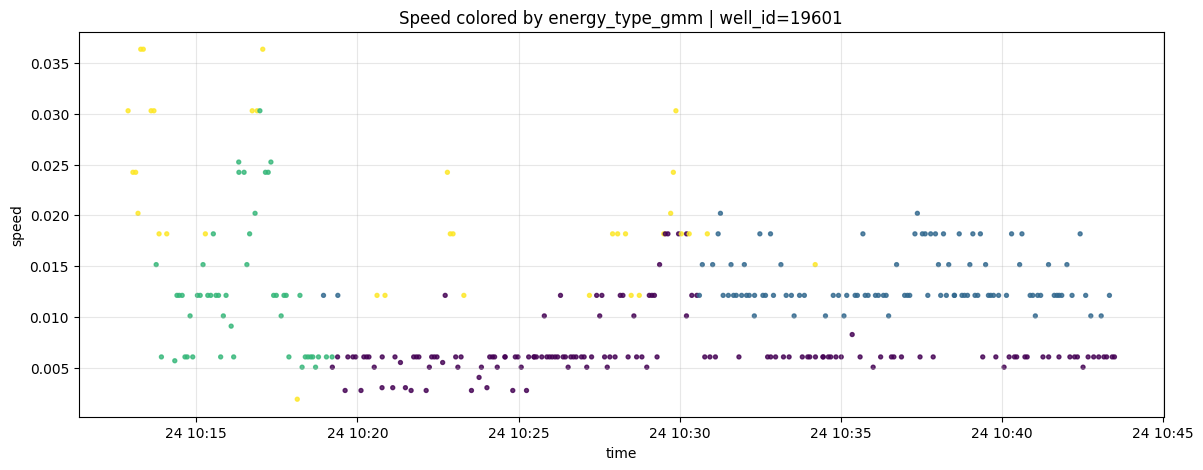

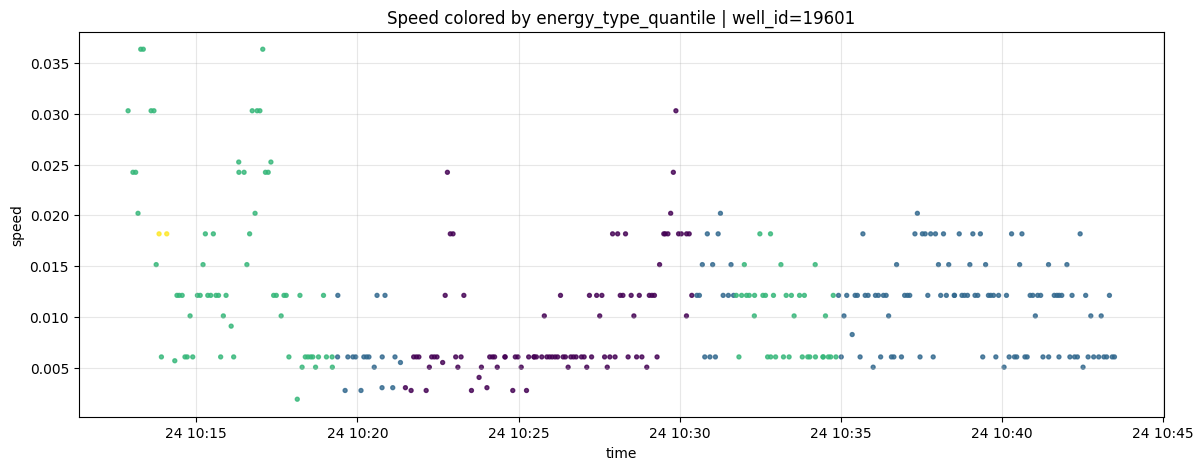

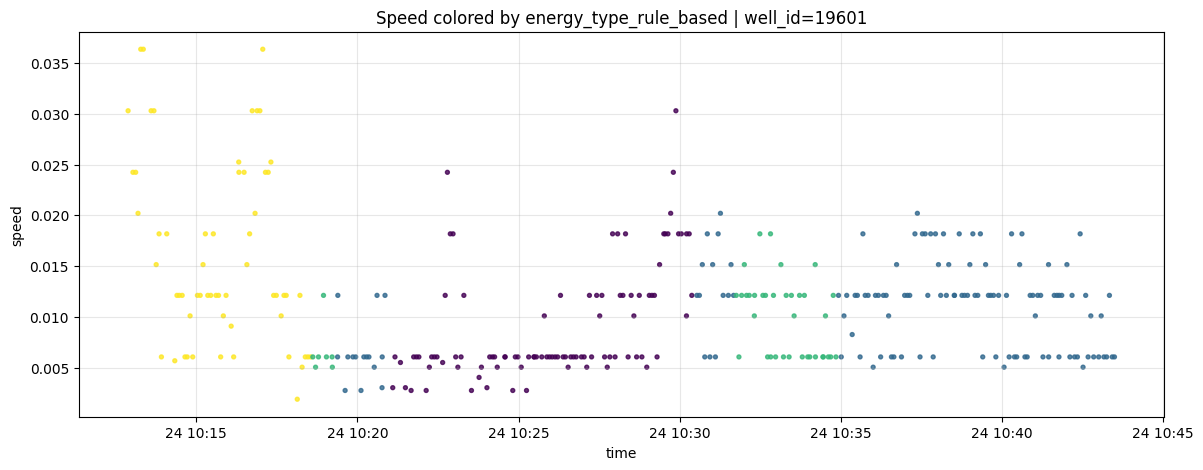

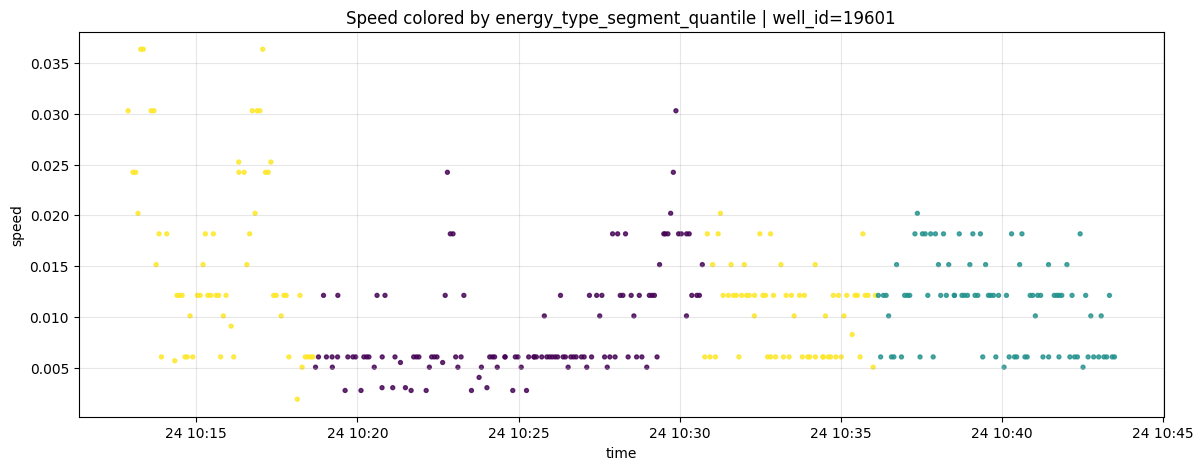

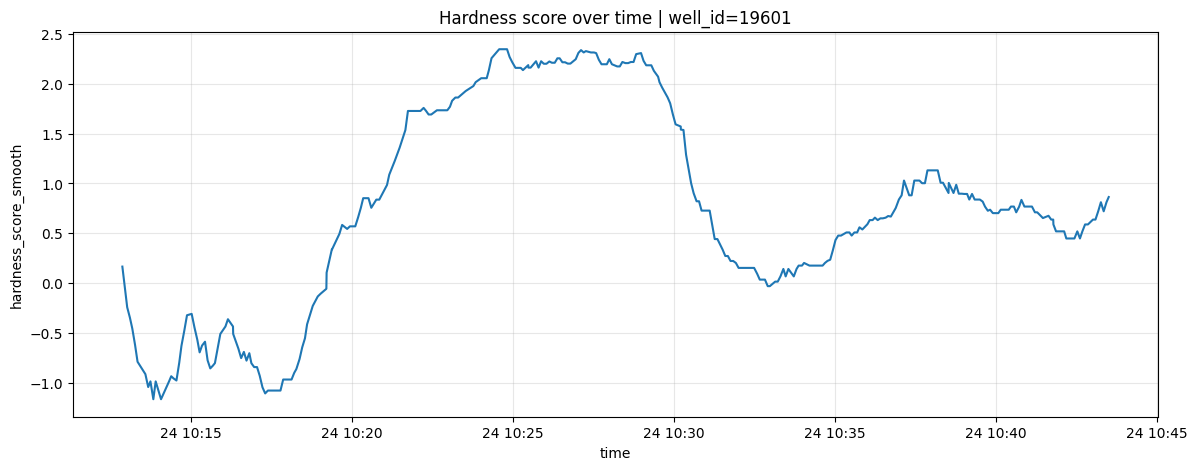

In [8]:
sample_well = df["well_id"].dropna().unique()[0]
tmp = df[df["well_id"] == sample_well].copy()

for type_col in segmentation_methods:
    code_map = {v: i for i, v in enumerate(sorted(tmp[type_col].dropna().unique()))}
    colors = tmp[type_col].map(code_map)

    plt.figure(figsize=(14, 5))
    plt.scatter(tmp["processing_time"], tmp["speed"], c=colors, s=8, alpha=0.8)
    plt.xlabel("time")
    plt.ylabel("speed")
    plt.title(f"Speed colored by {type_col} | well_id={sample_well}")
    plt.grid(True, alpha=0.3)
    plt.show()

plt.figure(figsize=(14, 5))
plt.plot(tmp["processing_time"], tmp["hardness_score_smooth"])
plt.xlabel("time")
plt.ylabel("hardness_score_smooth")
plt.title(f"Hardness score over time | well_id={sample_well}")
plt.grid(True, alpha=0.3)
plt.show()

## 8. Тест полезности labels/hardness для прогноза ROP

In [9]:
prediction_df = df.dropna(subset=[
    "speed",
    "hardness_score_smooth",
] + segmentation_methods).copy()

base_features = [
    "pressure_axis",
    "pressure_rotation",
    "rotation",
    "total_pressure",
    "pressure_balance",
    "axis_over_rot_pressure",
    "rot_pressure_over_axis",
    "rotation_efficiency",
    "axis_x_rotation",
    "rot_pressure_x_rotation",
    "energy_input_proxy",
    "log_energy_input_proxy",
]

hardness_features = base_features + [
    "hardness_score_smooth",
    "pseudo_mse_roll_median_60",
    "drilling_efficiency_roll_median_60",
    "formation_residual_roll_median_60",
]

target = "speed"

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(prediction_df, groups=prediction_df["well_id"]))

train_pred = prediction_df.iloc[train_idx].copy()
test_pred = prediction_df.iloc[test_idx].copy()

def fit_eval_numeric(features, model_name):
    model = Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ))
    ])

    model.fit(train_pred[features], train_pred[target])
    pred = model.predict(test_pred[features])

    return {
        "model": model_name,
        "MAE": mean_absolute_error(test_pred[target], pred),
        "RMSE": root_mean_squared_error(test_pred[target], pred),
        "R2": r2_score(test_pred[target], pred),
    }

results = []
results.append(fit_eval_numeric(base_features, "controls_only"))
results.append(fit_eval_numeric(hardness_features, "controls_plus_hardness_score"))

# Добавляем categorical label каждого метода поверх base_features
for method in segmentation_methods:
    features_num = base_features
    categorical_features = [method]

    preprocess = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", StandardScaler(), features_num),
        ],
        remainder="drop",
    )

    model = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.05,
            max_leaf_nodes=31,
            l2_regularization=0.01,
            random_state=RANDOM_STATE,
        ))
    ])

    model.fit(train_pred[features_num + categorical_features], train_pred[target])
    pred = model.predict(test_pred[features_num + categorical_features])

    results.append({
        "model": f"controls_plus_{method}",
        "MAE": mean_absolute_error(test_pred[target], pred),
        "RMSE": root_mean_squared_error(test_pred[target], pred),
        "R2": r2_score(test_pred[target], pred),
    })

compare = pd.DataFrame(results).sort_values("MAE")
display(compare)

baseline = compare[compare["model"] == "controls_only"].iloc[0]

compare_improvement = compare.copy()
compare_improvement["MAE_improvement_vs_controls"] = baseline["MAE"] - compare_improvement["MAE"]
compare_improvement["RMSE_improvement_vs_controls"] = baseline["RMSE"] - compare_improvement["RMSE"]
compare_improvement["R2_improvement_vs_controls"] = compare_improvement["R2"] - baseline["R2"]

display(compare_improvement.sort_values("R2_improvement_vs_controls", ascending=False))

,model,MAE,RMSE,R2
2,controls_plus_energy_type_kmeans,0.002453,0.003204,0.755430
3,controls_plus_energy_type_gmm,0.003119,0.004070,0.605323
1,controls_plus_hardness_score,0.003676,0.004743,0.464065
4,controls_plus_energy_type_quantile,0.003877,0.004996,0.405441
6,controls_plus_energy_type_segment_quantile,0.003894,0.005011,0.401795
5,controls_plus_energy_type_rule_based,0.003907,0.005031,0.396972
0,controls_only,0.004625,0.005852,0.184101


,model,MAE,RMSE,R2,MAE_improvement_vs_controls,RMSE_improvement_vs_controls,R2_improvement_vs_controls
2,controls_plus_energy_type_kmeans,0.002453,0.003204,0.755430,0.002172,0.002648,0.571329
3,controls_plus_energy_type_gmm,0.003119,0.004070,0.605323,0.001506,0.001782,0.421222
1,controls_plus_hardness_score,0.003676,0.004743,0.464065,0.000949,0.001109,0.279964
4,controls_plus_energy_type_quantile,0.003877,0.004996,0.405441,0.000748,0.000856,0.221339
6,controls_plus_energy_type_segment_quantile,0.003894,0.005011,0.401795,0.000731,0.000841,0.217694
5,controls_plus_energy_type_rule_based,0.003907,0.005031,0.396972,0.000718,0.000821,0.212871
0,controls_only,0.004625,0.005852,0.184101,0.000000,0.000000,0.000000


## 9. Итоговая таблица выбора метода

In [10]:
method_selection_rows = []

for method in segmentation_methods:
    summary = summaries[method]
    stability = stability_compare[stability_compare["method"] == method].iloc[0]
    phys = physical_scores_df[physical_scores_df["method"] == method].iloc[0]

    pred_row = compare_improvement[compare_improvement["model"] == f"controls_plus_{method}"].iloc[0]

    method_selection_rows.append({
        "method": method,
        "physical_monotonicity_score_0_5": phys["physical_monotonicity_score_0_5"],
        "median_changes_per_1000": stability["median_changes_per_1000"],
        "p95_changes_per_1000": stability["p95_changes_per_1000"],
        "MAE_improvement_vs_controls": pred_row["MAE_improvement_vs_controls"],
        "R2_improvement_vs_controls": pred_row["R2_improvement_vs_controls"],
    })

method_selection = pd.DataFrame(method_selection_rows)

display(
    method_selection.sort_values(
        ["physical_monotonicity_score_0_5", "median_changes_per_1000", "R2_improvement_vs_controls"],
        ascending=[False, True, False],
    )
)

,method,physical_monotonicity_score_0_5,median_changes_per_1000,p95_changes_per_1000,MAE_improvement_vs_controls,R2_improvement_vs_controls
4,energy_type_segment_quantile,5,5.305077,12.269939,0.000731,0.217694
3,energy_type_rule_based,5,20.833333,66.031969,0.000718,0.212871
2,energy_type_quantile,5,23.910252,67.519647,0.000748,0.221339
1,energy_type_gmm,4,251.101322,428.470825,0.001506,0.421222
0,energy_type_kmeans,4,375.678531,511.596175,0.002172,0.571329


## 10. Сохранение validation report

In [11]:
VALIDATION_REPORT_PATH = "rock_energy_all_methods_validation_report.json"

report = {
    "data_path": DATA_PATH,
    "segmentation_methods": segmentation_methods,
    "physical_scores": physical_scores_df.to_dict(orient="records"),
    "stability_compare": stability_compare.to_dict(orient="records"),
    "prediction_comparison": compare.to_dict(orient="records"),
    "prediction_improvement": compare_improvement.to_dict(orient="records"),
    "method_selection": method_selection.to_dict(orient="records"),
}

with open(VALIDATION_REPORT_PATH, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print("Saved:", VALIDATION_REPORT_PATH)

Saved: rock_energy_all_methods_validation_report.json


## 11. Как выбирать финальный метод

Смотреть нужно не на одну метрику, а на компромисс:

- высокая физическая монотонность;
- низкое `median_changes_per_1000`;
- hard-класс не должен быть просто максимальным pressure;
- хорошая переносимость между wells;
- `controls_plus_<method>` должен улучшать прогноз относительно `controls_only`.

Ожидаемый кандидат: `energy_type_segment_quantile`, если он даст лучшую temporal stability и физическую монотонность.